In [1]:
from transformers import pipeline

/Users/shaify/ai-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import matplotlib.pyplot as plt

In [3]:
import sys

Loading weights: 100%|████████████████████| 104/104 [00:00<00:00, 13006.37it/s]


Model loaded successfully!

Results of Sentiment Analysis:
--------------------------------------------------
Log: Suspicious file detected during scan.
Sentiment: NEGATIVE (Confidence: 0.98)
--------------------------------------------------
Log: Network traffic normal, no issues found.
Sentiment: NEGATIVE (Confidence: 0.70)
--------------------------------------------------
Log: Multiple failed login attempts detected.
Sentiment: NEGATIVE (Confidence: 1.00)
--------------------------------------------------
Log: System update completed successfully.
Sentiment: POSITIVE (Confidence: 1.00)
--------------------------------------------------
Log: High packet rate: possible DDoS attack.
Sentiment: NEGATIVE (Confidence: 1.00)
--------------------------------------------------


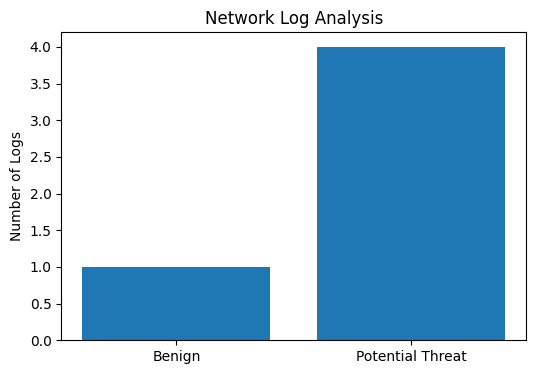

In [6]:
try:
    classifier = pipeline(
        "sentiment-analysis",
        model="distilbert-base-uncased-finetuned-sst-2-english"
    )
    print("Model loaded successfully!")

except Exception as e:
    print(f"Error loading model: {e}")
    sys.exit(1)

logs = [
    "Suspicious file detected during scan.",
    "Network traffic normal, no issues found.",
    "Multiple failed login attempts detected.",
    "System update completed successfully.",
    "High packet rate: possible DDoS attack."
]

results = []

for log in logs:
    if log.strip():
        result = classifier(log)[0]

        results.append({
            "log": log,
            "label": result["label"],
            "score": result["score"]
        })

print("\nResults of Sentiment Analysis:")
print("-" * 50)

for res in results:
    print(f"Log: {res['log']}")
    print(f"Sentiment: {res['label']} "
          f"(Confidence: {res['score']:.2f})")
    print("-" * 50)

positive_count = sum(
    1 for res in results if res["label"] == "POSITIVE"
)

negative_count = sum(
    1 for res in results if res["label"] == "NEGATIVE"
)

labels = ["Benign", "Potential Threat"]
counts = [positive_count, negative_count]

plt.figure(figsize=(6,4))
plt.bar(labels, counts)
plt.title("Network Log Analysis")
plt.ylabel("Number of Logs")
plt.show()